In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transforms3d.quaternions import quat2mat

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Libraries loaded.")

Libraries loaded.


## 1. Paths & basic helpers

In [46]:
data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu")
output_dir = data_dir / "analysis_output"
output_dir.mkdir(exist_ok=True, parents=True)

print(f"Data directory : {data_dir}")
print(f"Output directory: {output_dir}")

Data directory : /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu
Output directory: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu/analysis_output


In [47]:
def load_series(filename: str, col_name: str) -> pd.DataFrame:
    """
    Load a single-topic CSV with columns ['elapsed time', 'value'] and
    rename them to ['t', col_name].
    """
    df = pd.read_csv(data_dir / filename)
    if "elapsed time" not in df.columns or "value" not in df.columns:
        raise ValueError(f"{filename} does not have expected columns ['elapsed time', 'value']")
    return df[["elapsed time", "value"]].rename(columns={"elapsed time": "t", "value": col_name})

print("Helper functions defined.")

Helper functions defined.


## 2. Load core signals (IMU, orientation, velocity, RPM)

In [48]:
# --- IMU specific force (body frame)
ax = load_series("linear_acceleration_x.csv", "ax_b")
ay = load_series("linear_acceleration_y.csv", "ay_b")
az = load_series("linear_acceleration_z.csv", "az_b")

# --- Orientation (quaternion, world frame)
qx = load_series("pos_orientation_x.csv", "qx_w")
qy = load_series("pos_orientation_y.csv", "qy_w")
qz = load_series("pos_orientation_z.csv", "qz_w")
qw = load_series("pos_orientation_w.csv", "qw_w")

# --- Velocity (world frame)
vx = load_series("twist_linear_x.csv", "vx_w")
vy = load_series("twist_linear_y.csv", "vy_w")
vz = load_series("twist_linear_z.csv", "vz_w")

# --- Motor rpm (average)
rpm = load_series("average_motor_speed.csv", "rpm")
# If this is actually in 0.1 RPM units like your old script, scale here:
rpm["rpm"] *= 10.0

# Merge on time
dfs = [ax, ay, az, qx, qy, qz, qw, vx, vy, vz, rpm]
df = dfs[0]
for d in dfs[1:]:
    df = pd.merge(df, d, on="t", how="outer")

df = df.sort_values("t").interpolate().reset_index(drop=True)

t = df["t"].to_numpy()
t_rel = t - t.min()

print("Core signals loaded and merged.")
print(df.head())

Core signals loaded and merged.
          t      ax_b     ay_b      az_b      qx_w      qy_w      qz_w  \
0  0.000737       NaN      NaN       NaN  0.008741  0.010382  0.021067   
1  0.000790       NaN      NaN       NaN  0.008724  0.010417  0.021075   
2  0.000891  0.068670  0.52974  9.358740  0.008708  0.010451  0.021084   
3  0.000893 -0.034335  0.54936  9.402885  0.008692  0.010486  0.021093   
4  0.001644 -0.137340  0.56898  9.447030  0.008675  0.010521  0.021102   

       qw_w      vx_w      vy_w      vz_w           rpm  
0  0.999686       NaN       NaN       NaN           NaN  
1  0.999686 -0.011515  0.021399  0.017736           NaN  
2  0.999685 -0.011384  0.020881  0.016626           NaN  
3  0.999685 -0.011252  0.020363  0.015516  12420.053406  
4  0.999684 -0.011121  0.019846  0.014405  12392.040863  


## 3. Optional: load position error (for tracking error time series)

In [49]:
position_errors_available = False
pos_err_df = None

try:
    # Load reference and actual positions to calculate position error
    ref_x = load_series("ref_pos_x.csv", "ref_x")
    ref_y = load_series("ref_pos_y.csv", "ref_y")
    ref_z = load_series("ref_pos_z.csv", "ref_z")
    
    pos_x = load_series("pos_x.csv", "pos_x")
    pos_y = load_series("pos_y.csv", "pos_y")
    pos_z = load_series("pos_z.csv", "pos_z")
    
    # Merge reference positions
    pos_err_df = ref_x
    pos_err_df = pos_err_df.merge(ref_y, on="t", how="outer")
    pos_err_df = pos_err_df.merge(ref_z, on="t", how="outer")
    
    # Merge actual positions
    pos_err_df = pos_err_df.merge(pos_x, on="t", how="outer")
    pos_err_df = pos_err_df.merge(pos_y, on="t", how="outer")
    pos_err_df = pos_err_df.merge(pos_z, on="t", how="outer")
    
    # Sort and interpolate
    pos_err_df = pos_err_df.sort_values("t").interpolate().reset_index(drop=True)
    
    # Calculate errors (actual - reference)
    pos_err_df["err_x"] = pos_err_df["pos_x"] - pos_err_df["ref_x"]
    pos_err_df["err_y"] = pos_err_df["pos_y"] - pos_err_df["ref_y"]
    pos_err_df["err_z"] = pos_err_df["pos_z"] - pos_err_df["ref_z"]
    
    position_errors_available = True
    print("Position error calculated from reference and actual positions.")
    print(f"Position error stats:")
    print(f"  err_x: mean={pos_err_df['err_x'].mean():.4f} m, std={pos_err_df['err_x'].std():.4f} m")
    print(f"  err_y: mean={pos_err_df['err_y'].mean():.4f} m, std={pos_err_df['err_y'].std():.4f} m")
    print(f"  err_z: mean={pos_err_df['err_z'].mean():.4f} m, std={pos_err_df['err_z'].std():.4f} m")

except Exception as e:
    print(f"WARNING: Could not load position data to calculate tracking error")
    print(f"         {e}")
    print("         Tracking-error plots will be skipped unless you fix this path/format.")

Position error calculated from reference and actual positions.
Position error stats:
  err_x: mean=-0.0625 m, std=0.1070 m
  err_y: mean=0.1752 m, std=0.2219 m
  err_z: mean=0.0821 m, std=0.0909 m


## 4. Constants and rotation helpers

In [50]:
mass = 2.5  # kg
g = 9.81
g_world = np.array([0.0, 0.0, -g])

def R_wb(qw, qx, qy, qz):
    """
    Rotation matrix from world to body frame.
    transforms3d.quaternions.quat2mat([w, x, y, z]) returns body->world (R_bw).
    We need world->body, so we return its transpose.
    """
    R_bw = quat2mat([qw, qx, qy, qz])  # body -> world
    return R_bw.T                      # world -> body

## 5. Thrust & aerodynamic forces

In [51]:
def thrust_per_motor(rpm_val):
    # Same mapping as in your thrust stand analysis
    return 5.15e-8 * rpm_val**2 - 0.09e-3 * rpm_val - 1

# Total thrust (assuming 4 identical rotors)
T_total = 4.0 * thrust_per_motor(df["rpm"].to_numpy())

F_thrust_b = np.zeros((len(df), 3))
F_thrust_b[:, 2] = T_total  # thrust along +z_body

# IMU specific force in body frame (f_b = a - R^T g)
f_b = df[["ax_b", "ay_b", "az_b"]].to_numpy()

# Total non-gravitational force in body frame
F_sum_b = mass * f_b

# Aerodynamic force in body frame (residual = everything that is not thrust)
F_aero_b = F_sum_b - F_thrust_b

# Allocate arrays for world-frame forces
F_thrust_w = np.zeros_like(F_thrust_b)
F_aero_w   = np.zeros_like(F_thrust_b)
F_g_w      = np.zeros_like(F_thrust_b)
F_g_w[:]   = mass * g_world

# World-frame velocity for later |v|
V_w = df[["vx_w", "vy_w", "vz_w"]].to_numpy()
speed_w = np.linalg.norm(V_w, axis=1)

# World-frame acceleration (from IMU + orientation)
a_w = np.zeros_like(V_w)

for i, row in df.iterrows():
    Rwb = R_wb(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])  # world->body
    Rbw = Rwb.T                                                     # body->world

    # Rotate forces
    F_thrust_w[i] = Rbw @ F_thrust_b[i]
    F_aero_w[i]   = Rbw @ F_aero_b[i]

    # world-frame acceleration: a_w = R_bw * f_b + g_world
    fb_i = np.array([row["ax_b"], row["ay_b"], row["az_b"]])
    a_w[i] = Rbw @ fb_i + g_world

acc_norm = np.linalg.norm(a_w, axis=1)
F_aero_norm = np.linalg.norm(F_aero_w, axis=1)
F_thrust_norm = np.linalg.norm(F_thrust_w, axis=1)

print("Aerodynamic forces and world-frame acceleration computed.")


Aerodynamic forces and world-frame acceleration computed.


## 5b. Lift & drag decomposition in BODY frame

In [52]:
# 1) Body-frame velocity from world-frame velocity
V_b = np.zeros_like(V_w)
for i, row in df.iterrows():
    Rwb = R_wb(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])  # world -> body
    v_w = np.array([row["vx_w"], row["vy_w"], row["vz_w"]])
    V_b[i] = Rwb @ v_w

# 2) Unit velocity vector in body frame
V_b_norm = np.linalg.norm(V_b, axis=1)
eps = 1e-12
e_v_b = V_b / (V_b_norm[:, None] + eps)  # shape (N,3)

# 3) Scalar drag (positive if F_aero_b opposes motion)
#    D_b > 0 when aerodynamic force has a component against the velocity
D_b = -np.einsum("ij,ij->i", F_aero_b, e_v_b)  # shape (N,)

# 4) Parallel component of aero force along velocity (in body frame)
F_parallel_b = (np.einsum("ij,ij->i", F_aero_b, e_v_b)[:, None]) * e_v_b  # shape (N,3)

# 5) Drag and lift vectors in body frame
#    - Drag points opposite to velocity
#    - Lift is whatever is left after removing the parallel component
F_drag_b = -F_parallel_b          # along -e_v_b
F_lift_b = F_aero_b - F_parallel_b

# 6) Magnitudes for inspection / plotting
D_b_mag = np.linalg.norm(F_drag_b, axis=1)
L_b_mag = np.linalg.norm(F_lift_b, axis=1)

print("Computed body-frame lift/drag decomposition:")
print(f"  |V_b| min/max: {V_b_norm.min():.3f} / {V_b_norm.max():.3f} m/s")
print(f"  |F_drag_b| min/max: {D_b_mag.min():.3f} / {D_b_mag.max():.3f} N")
print(f"  |F_lift_b| min/max: {L_b_mag.min():.3f} / {L_b_mag.max():.3f} N")

Computed body-frame lift/drag decomposition:
  |V_b| min/max: nan / nan m/s
  |F_drag_b| min/max: nan / nan N
  |F_lift_b| min/max: nan / nan N


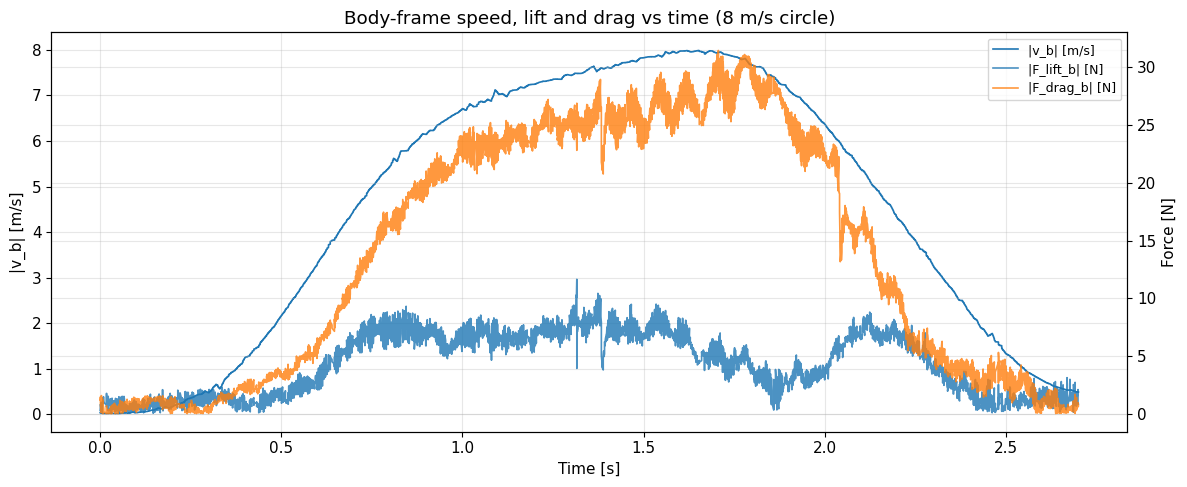

In [53]:
# Quick sanity check: lift & drag vs speed in body frame (same time window mask)
# Note: This uses the mask defined later, so run the time window section first if needed
try:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(t_rel[mask], V_b_norm[mask], label="|v_b| [m/s]", linewidth=1.2)
    ax2 = ax.twinx()
    ax2.plot(t_rel[mask], L_b_mag[mask], label="|F_lift_b| [N]", linewidth=1.2, alpha=0.8)
    ax2.plot(t_rel[mask], D_b_mag[mask], label="|F_drag_b| [N]", linewidth=1.2, alpha=0.8)

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("|v_b| [m/s]")
    ax2.set_ylabel("Force [N]")
    ax.grid(True, alpha=0.3)
    ax.set_title("Body-frame speed, lift and drag vs time (8 m/s circle)")

    # Merge legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()
except NameError:
    print("Skipping sanity plot (mask not yet defined - run time window section first)")

## 6. Time window selection

In [54]:
# You can tighten this to the actual circle portion (e.g. by hand-picking
# the time interval). For now use full log; tweak t_min/t_max as needed.

t_min = t_rel.min()
#t_max = t_rel.max()
t_max = 2.7
mask = (t_rel >= t_min) & (t_rel <= t_max)

t_plot = t_rel[mask]

speed_plot = speed_w[mask]
acc_norm_plot = acc_norm[mask]
F_aero_norm_plot = F_aero_norm[mask]
F_thrust_norm_plot = F_thrust_norm[mask]

print(f"Time window: {t_min:.2f} s to {t_max:.2f} s")

Time window: 0.00 s to 2.70 s


## 7. Tracking error time series (if available)

In [55]:
if position_errors_available:
    # Interpolate position errors to the same time base as df
    err_t = pos_err_df["t"].to_numpy()
    err_x = np.interp(t, err_t, pos_err_df["err_x"].to_numpy())
    err_y = np.interp(t, err_t, pos_err_df["err_y"].to_numpy())
    err_z = np.interp(t, err_t, pos_err_df["err_z"].to_numpy())

    err_xy = np.sqrt(err_x**2 + err_y**2)
    err_3d = np.sqrt(err_x**2 + err_y**2 + err_z**2)

    err_x_plot = err_x[mask]
    err_y_plot = err_y[mask]
    err_z_plot = err_z[mask]
    err_xy_plot = err_xy[mask]
    err_3d_plot = err_3d[mask]

    print("Tracking-error signals interpolated to IMU time base.")
else:
    err_x_plot = err_y_plot = err_z_plot = err_xy_plot = err_3d_plot = None
    print("No position error available -> error plots will be skipped.")

Tracking-error signals interpolated to IMU time base.


## 8. Plots – Combined time series

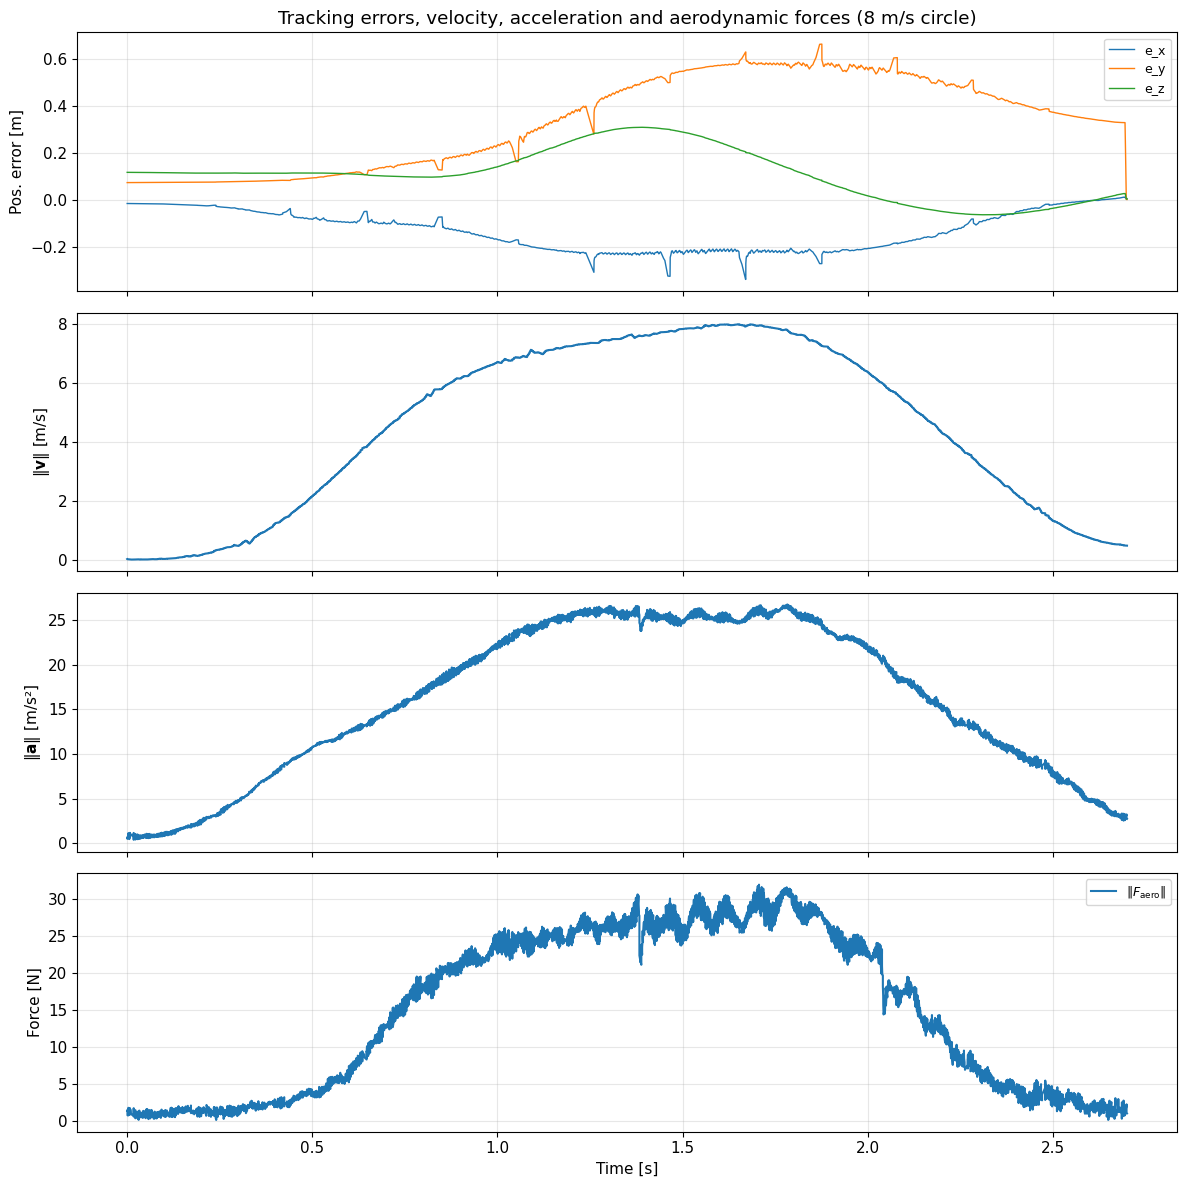

In [56]:
# 8.1 Combined figure: tracking error, |v|, |a|, |F_aero|
if position_errors_available:
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    # (1) Position errors
    axes[0].plot(t_plot, err_x_plot, label="e_x", linewidth=1.0)
    axes[0].plot(t_plot, err_y_plot, label="e_y", linewidth=1.0)
    axes[0].plot(t_plot, err_z_plot, label="e_z", linewidth=1.0)
    axes[0].set_ylabel("Pos. error [m]")
    axes[0].legend(loc="upper right", fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title("Tracking errors, velocity, acceleration and aerodynamic forces (8 m/s circle)")

    # (2) Velocity magnitude
    axes[1].plot(t_plot, speed_plot, linewidth=1.5)
    axes[1].set_ylabel(r"$\|\mathbf{v}\|$ [m/s]")
    axes[1].grid(True, alpha=0.3)

    # (3) Acceleration magnitude
    axes[2].plot(t_plot, acc_norm_plot, linewidth=1.5)
    axes[2].set_ylabel(r"$\|\mathbf{a}\|$ [m/s²]")
    axes[2].grid(True, alpha=0.3)

    # (4) Aerodynamic force magnitude
    axes[3].plot(t_plot, F_aero_norm_plot, label=r"$\|F_{\mathrm{aero}}\|$", linewidth=1.5)
    axes[3].set_ylabel("Force [N]")
    axes[3].set_xlabel("Time [s]")
    axes[3].legend(loc="upper right", fontsize=9)
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

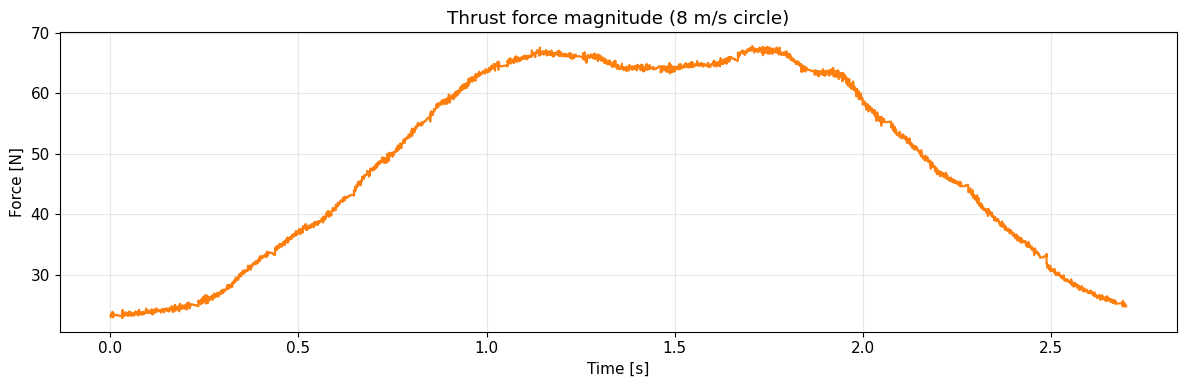

In [57]:
# 8.2 Thrust force magnitude
if position_errors_available:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_plot, F_thrust_norm_plot, linewidth=1.5, color='tab:orange')
    ax.set_ylabel("Force [N]")
    ax.set_xlabel("Time [s]")
    ax.set_title(r"Thrust force magnitude (8 m/s circle)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8.2 Aerodynamic force components (world frame)

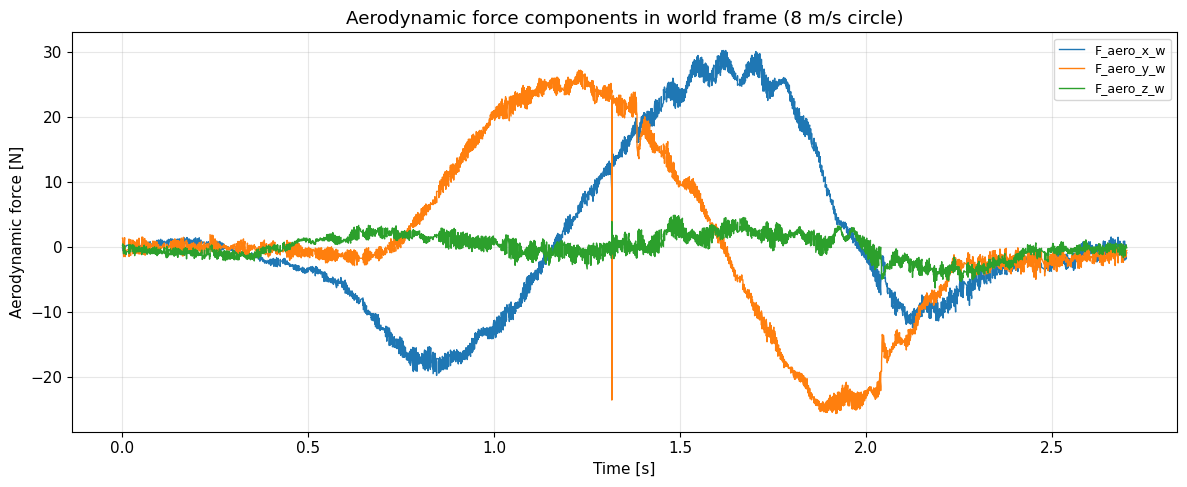

In [58]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_plot, F_aero_w[mask, 0], label="F_aero_x_w", linewidth=1.0)
ax.plot(t_plot, F_aero_w[mask, 1], label="F_aero_y_w", linewidth=1.0)
ax.plot(t_plot, F_aero_w[mask, 2], label="F_aero_z_w", linewidth=1.0)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Aerodynamic force [N]")
ax.set_title("Aerodynamic force components in world frame (8 m/s circle)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. CSV export for LaTeX / pgfplots

In [59]:
# Downsample the data to reduce file size for pgfplots
# Keep every Nth point to reduce from ~2700 points to ~270 points
downsample_factor = 10

export = {
    "time": t_plot[::downsample_factor],
    "speed_w": speed_plot[::downsample_factor],
    "acc_norm": acc_norm_plot[::downsample_factor],
    "F_aero_norm": F_aero_norm_plot[::downsample_factor],
    "F_thrust_norm": F_thrust_norm_plot[::downsample_factor],
    "F_aero_x_w": F_aero_w[mask, 0][::downsample_factor],
    "F_aero_y_w": F_aero_w[mask, 1][::downsample_factor],
    "F_aero_z_w": F_aero_w[mask, 2][::downsample_factor],
    "F_lift_b_norm": L_b_mag[mask][::downsample_factor],
    "F_drag_b_norm": D_b_mag[mask][::downsample_factor],
}

if position_errors_available:
    export.update({
        "err_x": err_x_plot[::downsample_factor],
        "err_y": err_y_plot[::downsample_factor],
        "err_z": err_z_plot[::downsample_factor],
        "err_xy": err_xy_plot[::downsample_factor],
        "err_3d": err_3d_plot[::downsample_factor],
    })

export_df = pd.DataFrame(export)
csv_path = output_dir / "circle_8mps_imu_timeseries.csv"
export_df.to_csv(csv_path, index=False)
print(f"Exported time-series data to: {csv_path}")
print(f"Downsampled from {len(t_plot)} to {len(export_df)} points (factor: {downsample_factor})")
print(export_df.head())


Exported time-series data to: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu/analysis_output/circle_8mps_imu_timeseries.csv
Downsampled from 5917 to 592 points (factor: 10)
       time   speed_w  acc_norm  F_aero_norm  F_thrust_norm  F_aero_x_w  \
0  0.000000       NaN       NaN          NaN            NaN         NaN   
1  0.004507  0.021142  0.840862     0.923924      23.546137    0.368923   
2  0.009321  0.015047  1.028815     1.575020      23.664465    0.083193   
3  0.017720  0.014027  0.788149     0.625213      23.352731    0.145893   
4  0.027960  0.017900  0.822739     0.870419      23.283406   -0.200632   

   F_aero_y_w  F_aero_z_w  F_lift_b_norm  F_drag_b_norm     err_x     err_y  \
0         NaN         NaN            NaN            NaN       NaN       NaN   
1   -0.388544   -0.752705       0.520054       0.763662 -0.016061  0.073119   
2   -1.040951   -1.179062       1.461645       0.586756 -0.016114  0.073158   
3   -0.254282   -0.552220       0.5

In [60]:
# Also copy to the main data directory for LaTeX
import shutil
latex_data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/circle")
latex_csv_path = latex_data_dir / "circle_8mps_imu_timeseries.csv"
shutil.copy(csv_path, latex_csv_path)
print(f"Copied to LaTeX data directory: {latex_csv_path}")


Copied to LaTeX data directory: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/circle/circle_8mps_imu_timeseries.csv
